# Grid Search Analysis

Visualize results from the (σ₀, σ, η) parameter sweep.
Loads pre-computed per-triple `.npz` files and the gathered CSV/grid arrays.

Plots:
1. d' heatmaps (two slice orientations)
2. ISI=16 percentile band analysis (top/middle/bottom 10%)
3. ROC curves per ISI for top-percentile triples
4. Hit vs FA score distributions
5. Parameter sensitivity (marginal d' curves)

In [12]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.dpi'] = 120

# ── Point this to your grid search output directory ──
RESULTS_DIR = '/om2/user/bjmedina/auditory-memory/memory/reports/figures/2d_grid_search/slurm_20260317'

# Load grid arrays
grid = np.load(os.path.join(RESULTS_DIR, 'grid_search_results.npz'))
sigma0_grid = grid['sigma0_grid']
sigma_grid = grid['sigma_grid']
eta_grid = grid['eta_grid']
ISI_VALUES = tuple(grid['isi_values'].astype(int))

results = {isi: grid[f'dprime_isi{isi}'] for isi in ISI_VALUES}

# Load master CSV
df = pd.read_csv(os.path.join(RESULTS_DIR, 'grid_search_master.csv'))

PER_TRIPLE_DIR = os.path.join(RESULTS_DIR, 'per_triple')

def load_triple(s0, sig, eta):
    fname = f's0={s0:.3f}_sig={sig:.3f}_eta={eta:.3f}.npz'
    return np.load(os.path.join(PER_TRIPLE_DIR, fname), allow_pickle=True)

print(f'Grid: {len(sigma0_grid)} x {len(sigma_grid)} x {len(eta_grid)} = {len(df)} triples')
print(f'ISI values: {ISI_VALUES}')
print(f'sigma0: {sigma0_grid}')
print(f'sigma:  {sigma_grid}')
print(f'eta:    {eta_grid}')

Grid: 8 x 7 x 7 = 392 triples
ISI values: (0, 2, 8, 16)
sigma0: [0.  0.1 0.2 0.3 0.5 0.6 0.8 1. ]
sigma:  [0.    0.025 0.05  0.1   0.15  0.2   0.3  ]
eta:    [0.    0.005 0.01  0.02  0.05  0.1   0.2  ]


## d' Heatmaps: d'(σ, η) sliced by σ₀

Rows = ISI, Columns = σ₀ level. Each panel shows d' as a function of diffusive noise (σ) and drift step (η).

/tmp/ipykernel_3086296/2765150846.py:27: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


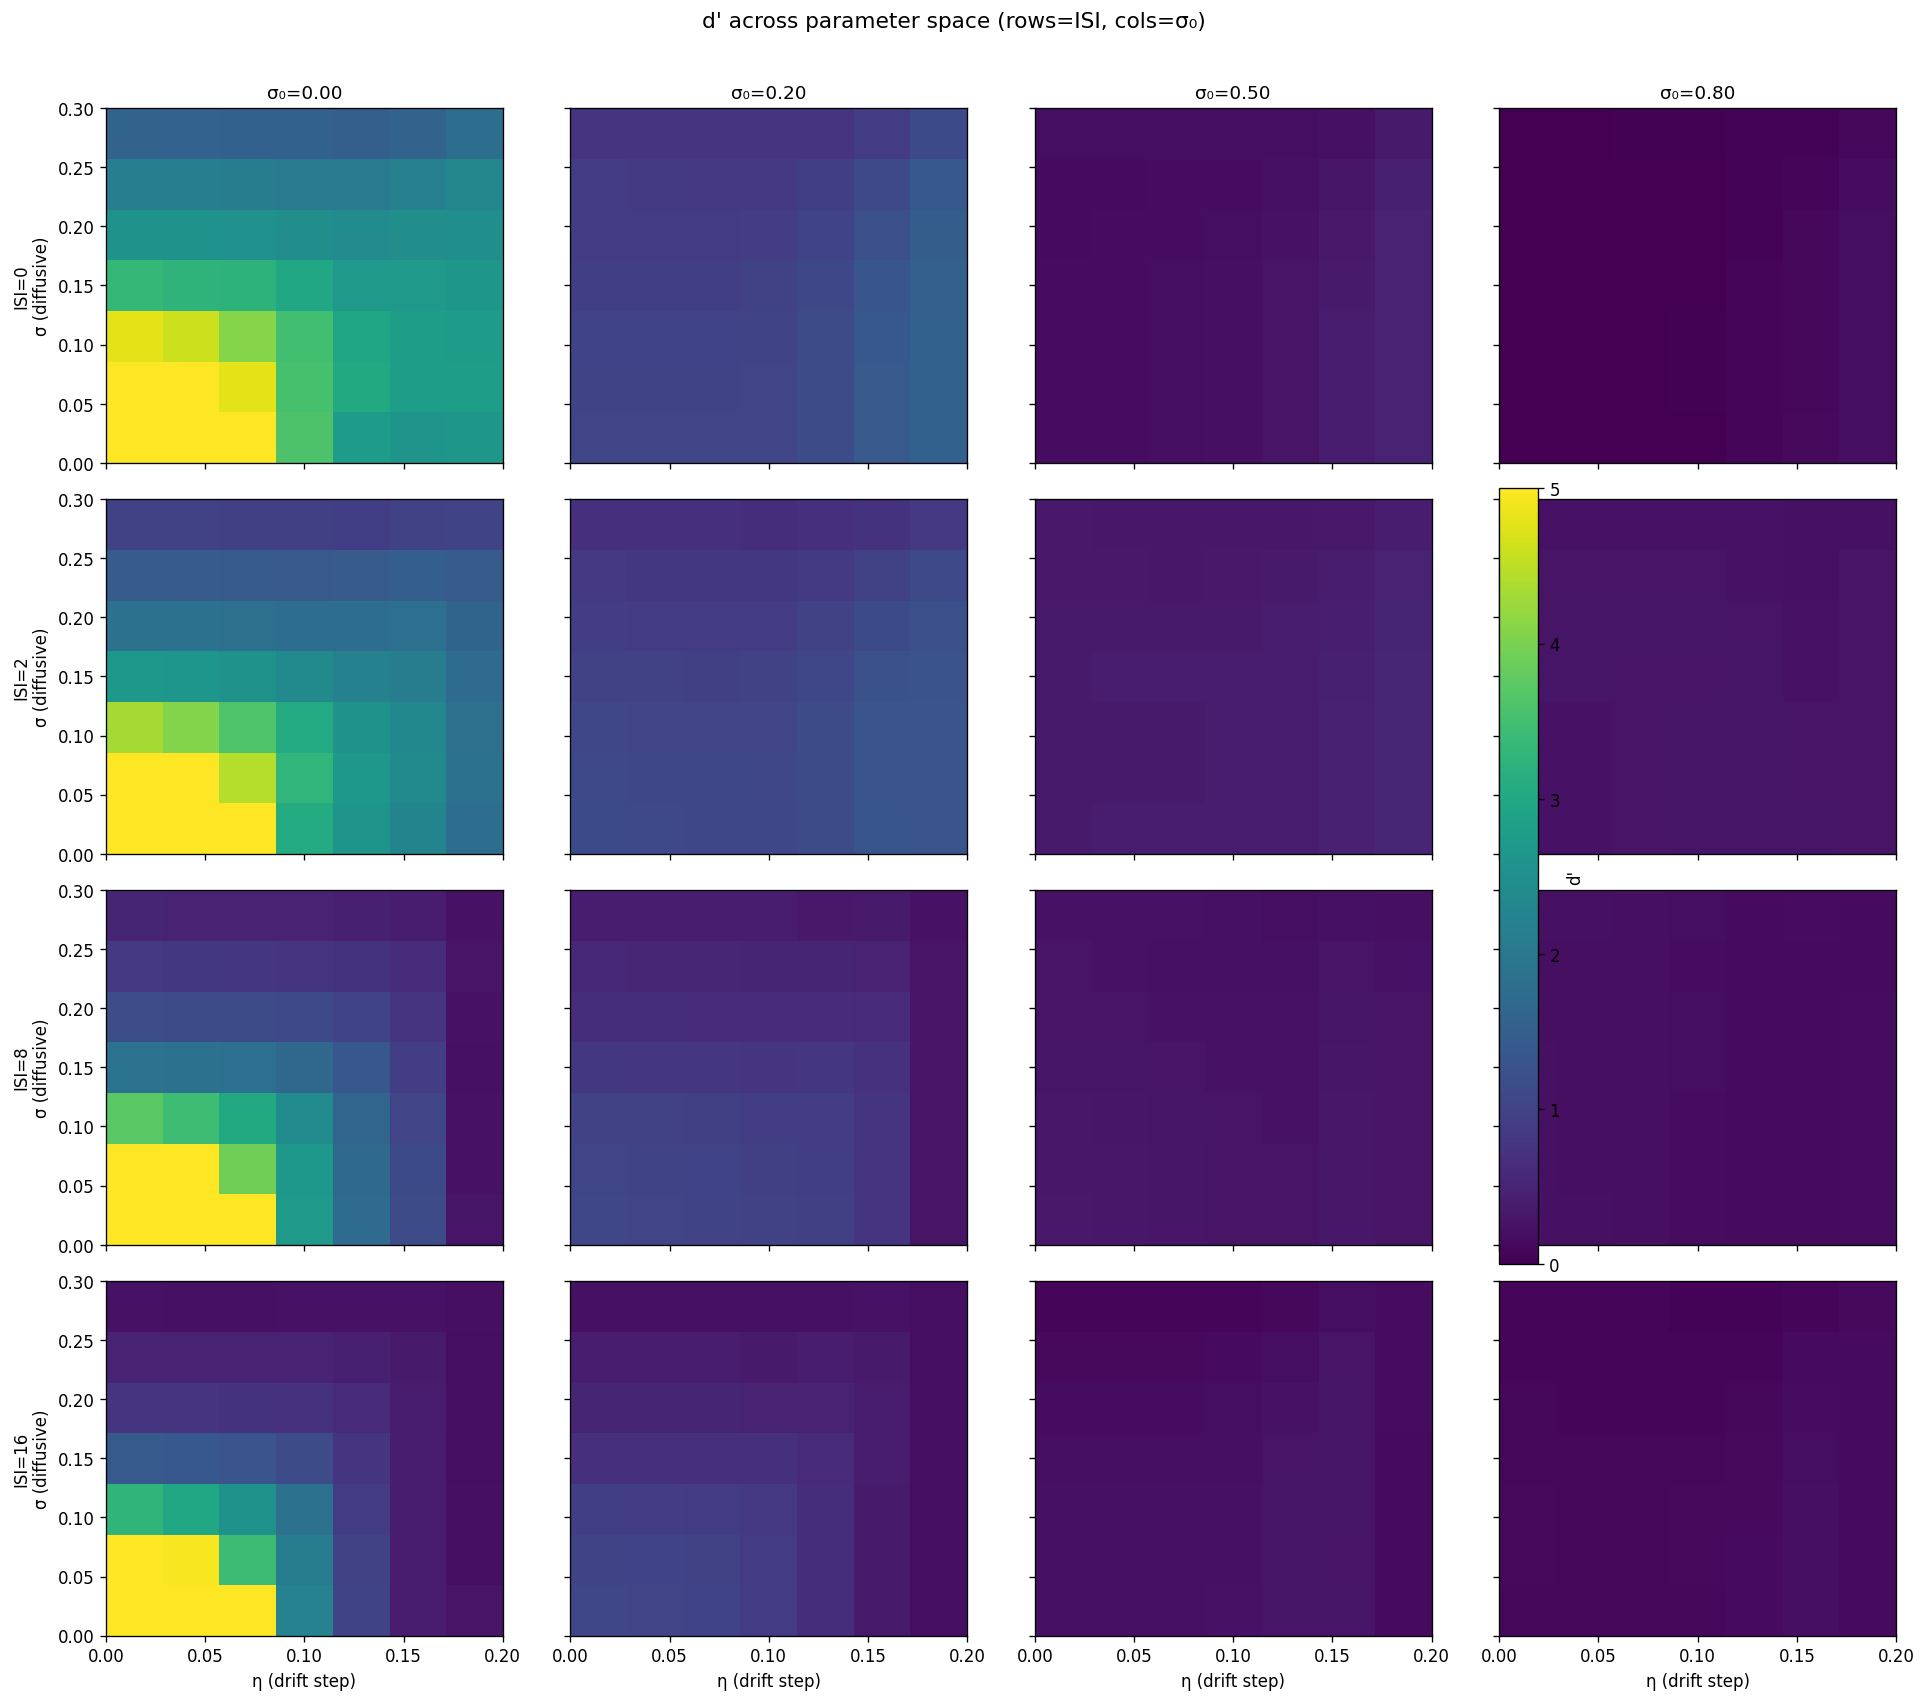

In [13]:
s0_slice_indices = [0, 2, 4, 6]  # 0.0, 0.25, 0.75, 1.5

fig, axes = plt.subplots(len(ISI_VALUES), len(s0_slice_indices),
                         figsize=(4 * len(s0_slice_indices), 3.5 * len(ISI_VALUES)),
                         sharex=True, sharey=True)

vmin = 0
vmax = min(np.nanmax([results[isi] for isi in ISI_VALUES]), 5.0)

for row, isi in enumerate(ISI_VALUES):
    for col, i_s0 in enumerate(s0_slice_indices):
        ax = axes[row, col]
        data = results[isi][i_s0, :, :]  # [n_sigma, n_eta]
        im = ax.imshow(data, aspect='auto', origin='lower',
                       vmin=vmin, vmax=vmax, cmap='viridis',
                       extent=[eta_grid[0], eta_grid[-1],
                               sigma_grid[0], sigma_grid[-1]])
        if row == 0:
            ax.set_title(f'\u03c3\u2080={sigma0_grid[i_s0]:.2f}', fontsize=11)
        if col == 0:
            ax.set_ylabel(f'ISI={isi}\n\u03c3 (diffusive)', fontsize=10)
        if row == len(ISI_VALUES) - 1:
            ax.set_xlabel('\u03b7 (drift step)', fontsize=10)

fig.suptitle("d' across parameter space (rows=ISI, cols=\u03c3\u2080)", fontsize=13, y=1.01)
fig.colorbar(im, ax=axes, shrink=0.6, label="d'")
fig.tight_layout()
plt.show()

## d' Heatmaps: d'(σ₀, η) sliced by σ

Complementary view: fix diffusive noise, sweep encoding noise vs drift.

/tmp/ipykernel_3086296/212261792.py:24: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


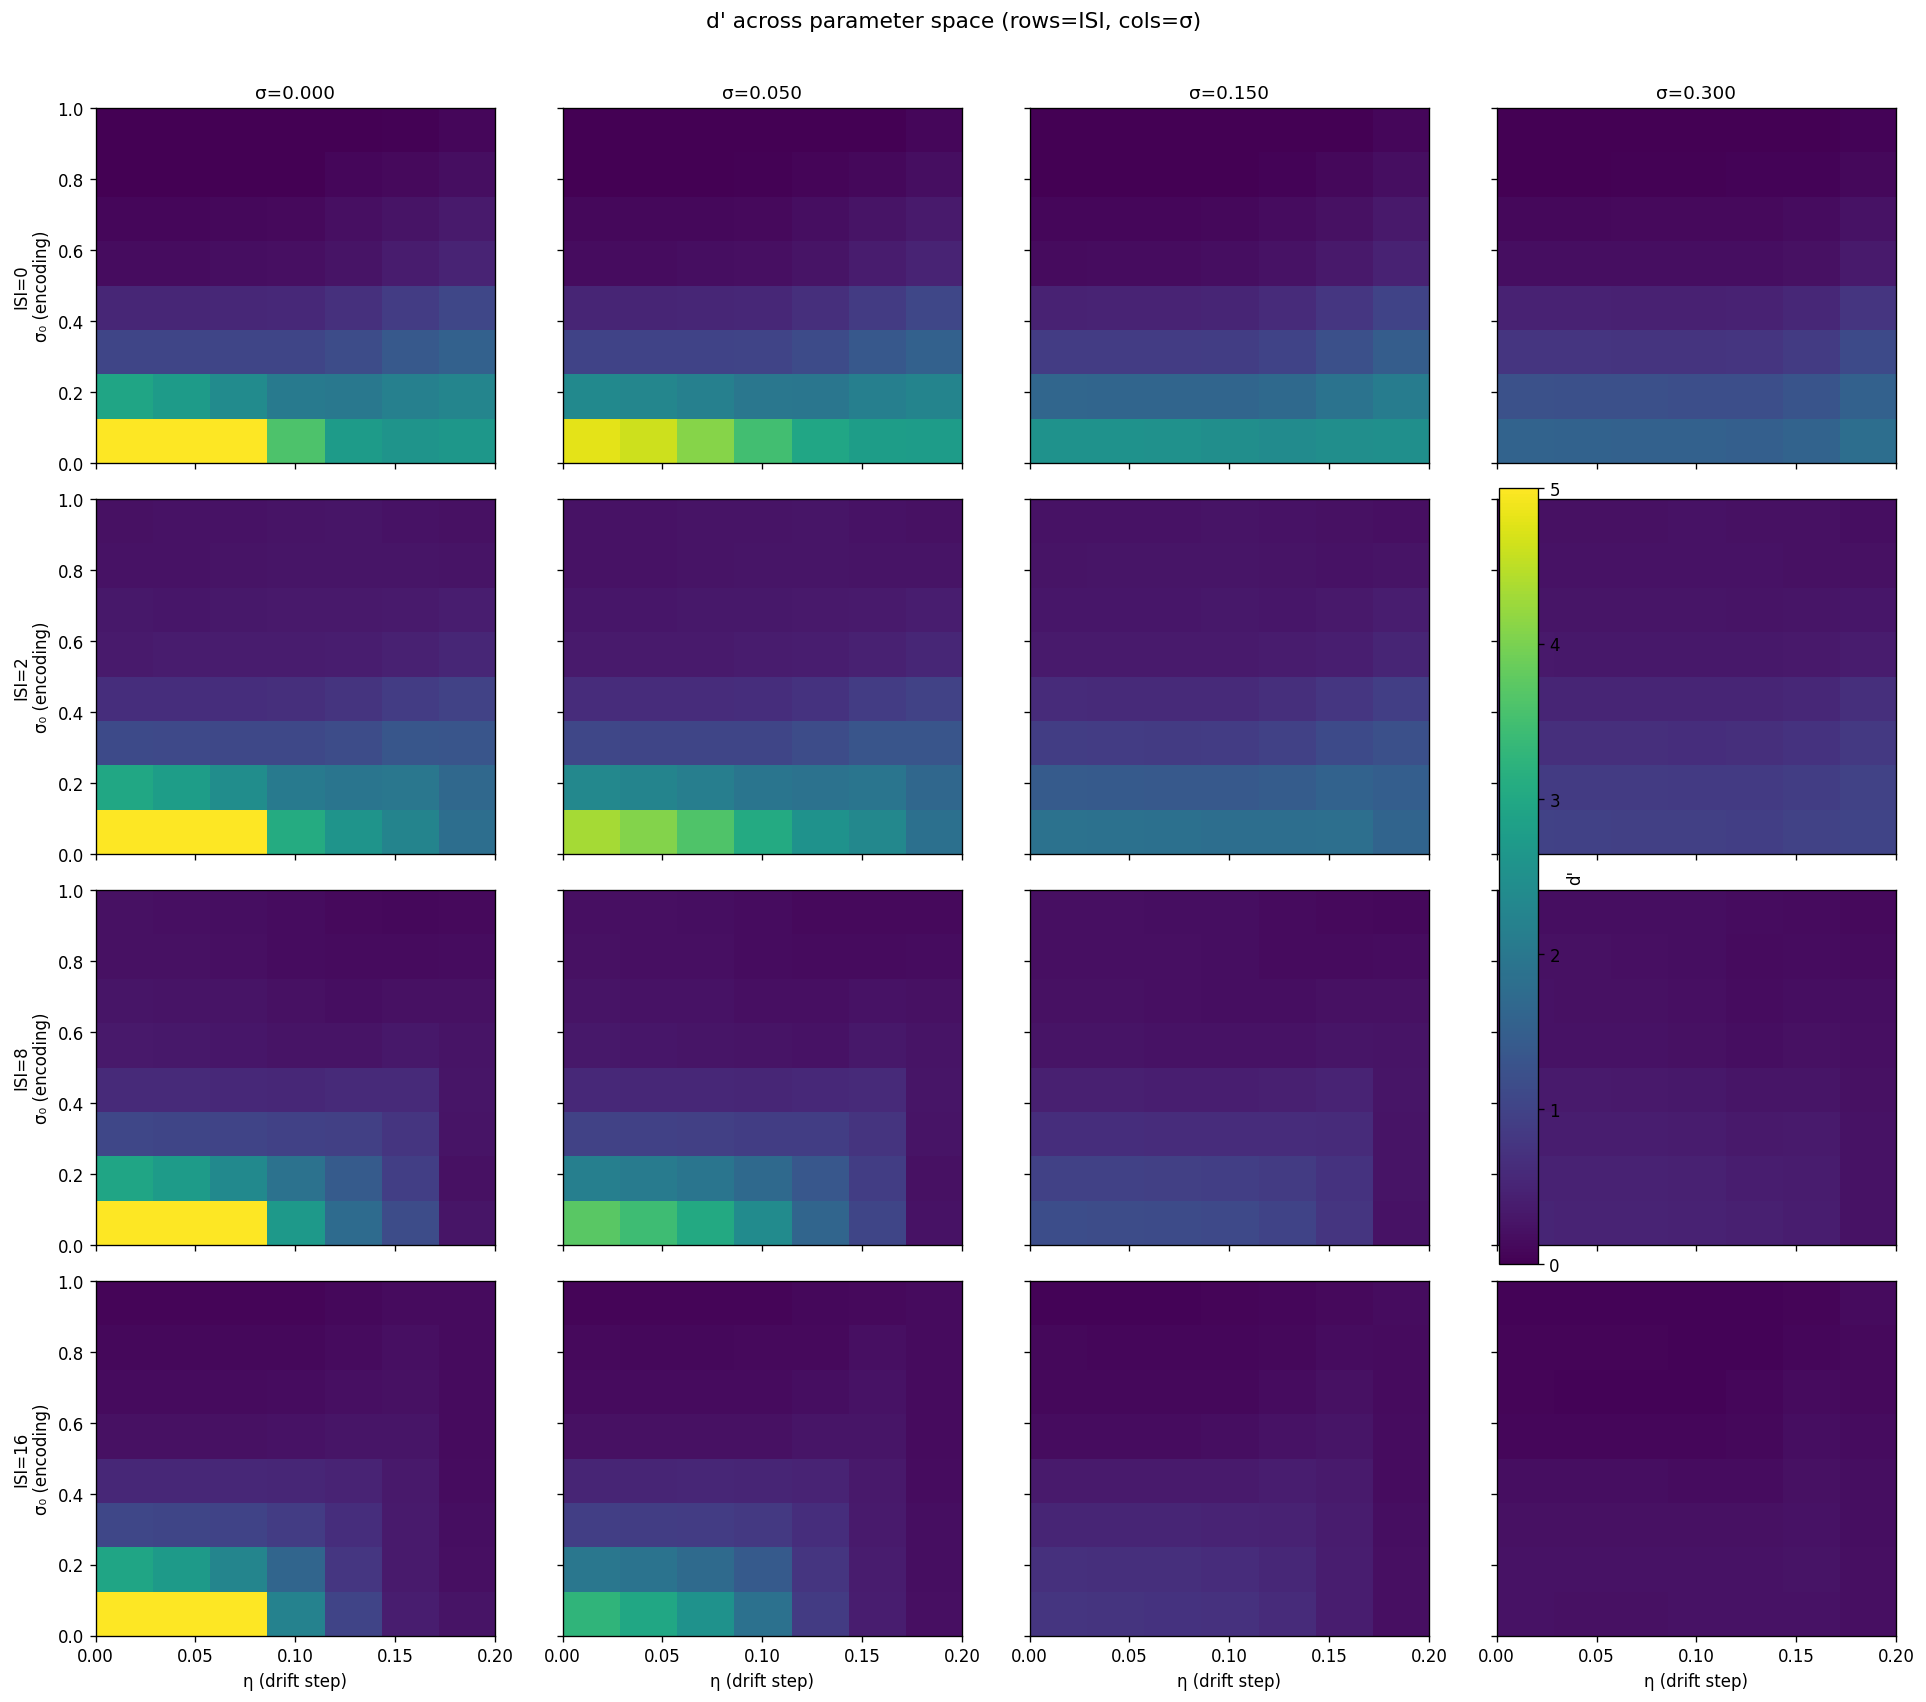

In [14]:
sig_slice_indices = [0, 2, 4, 6]  # 0.0, 0.05, 0.15, 0.3

fig, axes = plt.subplots(len(ISI_VALUES), len(sig_slice_indices),
                         figsize=(4 * len(sig_slice_indices), 3.5 * len(ISI_VALUES)),
                         sharex=True, sharey=True)

for row, isi in enumerate(ISI_VALUES):
    for col, i_sig in enumerate(sig_slice_indices):
        ax = axes[row, col]
        data = results[isi][:, i_sig, :]  # [n_sigma0, n_eta]
        im = ax.imshow(data, aspect='auto', origin='lower',
                       vmin=vmin, vmax=vmax, cmap='viridis',
                       extent=[eta_grid[0], eta_grid[-1],
                               sigma0_grid[0], sigma0_grid[-1]])
        if row == 0:
            ax.set_title(f'\u03c3={sigma_grid[i_sig]:.3f}', fontsize=11)
        if col == 0:
            ax.set_ylabel(f'ISI={isi}\n\u03c3\u2080 (encoding)', fontsize=10)
        if row == len(ISI_VALUES) - 1:
            ax.set_xlabel('\u03b7 (drift step)', fontsize=10)

fig.suptitle("d' across parameter space (rows=ISI, cols=\u03c3)", fontsize=13, y=1.01)
fig.colorbar(im, ax=axes, shrink=0.6, label="d'")
fig.tight_layout()
plt.show()

## ISI=16 Performance: Percentile Band Analysis

Rank all parameter triples by d' at ISI=16, then compare three bands:
- **Top 10%** — best long-delay memory
- **Middle 10%** (45th–55th percentile) — median performers
- **Bottom 10%** — worst long-delay memory

Goal: inspect which (σ₀, σ, η) values cluster in each band.

In [ ]:
# ── Percentile bands based on d' at ISI=16 ──
col = 'dprime_isi16'

p_top = df[col].quantile(0.90)
p_mid_lo = df[col].quantile(0.45)
p_mid_hi = df[col].quantile(0.55)
p_bot = df[col].quantile(0.10)

top_band = df[df[col] >= p_top].copy()
mid_band = df[(df[col] >= p_mid_lo) & (df[col] <= p_mid_hi)].copy()
bot_band = df[df[col] <= p_bot].copy()

bands = [('Top 10%', top_band, 'tab:green'),
         ('Middle 10%', mid_band, 'tab:blue'),
         ('Bottom 10%', bot_band, 'tab:red')]

# ── Summary stats ──
for name, band, _ in bands:
    print(f'\n=== {name} (n={len(band)}, d\'@ISI16 range: {band[col].min():.2f}–{band[col].max():.2f}) ===')
    print(band[['sigma0', 'sigma', 'eta', 'dprime_isi0', 'dprime_isi16']].describe().round(3).to_string())

# ── Plot 1: Mean ISI decay curves per band ──
isi_arr = np.array(ISI_VALUES)

fig, ax = plt.subplots(figsize=(7, 5))
for name, band, color in bands:
    means = [band[f'dprime_isi{isi}'].mean() for isi in ISI_VALUES]
    sems = [band[f'dprime_isi{isi}'].sem() for isi in ISI_VALUES]
    ax.errorbar(isi_arr, means, yerr=sems, marker='o', capsize=4,
                color=color, label=f'{name} (n={len(band)})', linewidth=2)
ax.set_xlabel('ISI', fontsize=12)
ax.set_ylabel("Mean d'", fontsize=12)
ax.set_title("ISI Decay by d'@ISI=16 Percentile Band", fontsize=13)
ax.legend(fontsize=10)
ax.set_xticks(isi_arr)
fig.tight_layout()
plt.show()

# ── Plot 2: Parameter distributions per band ──
params = [('sigma0', 'σ₀ (encoding noise)'),
          ('sigma', 'σ (diffusive noise)'),
          ('eta', 'η (drift step)')]

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
for ax, (param, label) in zip(axes, params):
    for name, band, color in bands:
        vals = band[param].values
        ax.hist(vals, bins=15, alpha=0.4, color=color, label=name, density=True)
        ax.axvline(vals.mean(), color=color, linestyle='--', linewidth=1.5)
    ax.set_xlabel(label, fontsize=11)
    ax.set_ylabel('Density', fontsize=11)
    ax.legend(fontsize=9)
fig.suptitle("Parameter Distributions by d'@ISI=16 Percentile Band\n(dashed = band mean)",
             fontsize=13, y=1.03)
fig.tight_layout()
plt.show()

## ROC Curves for Top-Percentile Triples

Full ROC (FPR vs TPR) per ISI for triples in the top 10% by d'@ISI=16. Shows whether the ISI effect is driven by hits shifting vs FA shifting.

In [ ]:
isi_colors = {0: 'green', 2: 'blue', 8:'red', 16: 'orange'}
top = top_band.nlargest(6, col)
n_triples = min(len(top), 6)
ncols = 3
nrows = int(np.ceil(n_triples / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4.5 * nrows))
axes = np.atleast_2d(axes)

for idx, (_, row) in enumerate(top.head(n_triples).iterrows()):
    ax = axes.flat[idx]
    data = load_triple(row['sigma0'], row['sigma'], row['eta'])
    for isi in ISI_VALUES:
        fpr = data[f'roc_fpr_isi{isi}']
        tpr = data[f'roc_tpr_isi{isi}']
        auc = float(data[f'auc_isi{isi}'])
        if len(fpr) > 0:
            ax.plot(fpr, tpr, color=isi_colors[isi], linewidth=2,
                    label=f'ISI={isi} (AUC={auc:.2f})')
    ax.plot([0, 1], [0, 1], 'k--', linewidth=0.5, alpha=0.5)
    ax.set_title(f'\u03c3\u2080={row["sigma0"]:.2f}, \u03c3={row["sigma"]:.3f}, \u03b7={row["eta"]:.3f}',
                 fontsize=10)
    ax.set_xlabel('FPR')
    ax.set_ylabel('TPR')
    ax.legend(fontsize=8)
    ax.set_aspect('equal')

# Hide unused axes
for idx in range(n_triples, nrows * ncols):
    axes.flat[idx].set_visible(False)

fig.suptitle('ROC Curves per ISI (top percentile triples)', fontsize=13, y=1.01)
fig.tight_layout()
plt.show()

## Score Distributions: Hit vs FA

Overlapping histograms showing how hit score distributions shift relative to FA scores across ISI conditions.

In [ ]:
fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4 * nrows))
axes = np.atleast_2d(axes)

for idx, (_, row) in enumerate(top.head(n_triples).iterrows()):
    ax = axes.flat[idx]
    data = load_triple(row['sigma0'], row['sigma'], row['eta'])
    fa = data['fa_scores']

    # Determine bin range across all scores
    all_scores = [fa]
    for isi in ISI_VALUES:
        h = data[f'hit_scores_isi{isi}']
        if len(h) > 0:
            all_scores.append(h)
    combined = np.concatenate(all_scores)
    bins = np.linspace(np.percentile(combined, 1), np.percentile(combined, 99), 40)

    ax.hist(fa, bins=bins, alpha=0.4, color='gray', label='FA', density=True)
    for isi, color in isi_colors.items():
        h = data[f'hit_scores_isi{isi}']
        if len(h) > 0:
            ax.hist(h, bins=bins, alpha=0.4, color=color,
                    label=f'Hit ISI={isi}', density=True)

    ax.set_title(f'\u03c3\u2080={row["sigma0"]:.2f}, \u03c3={row["sigma"]:.3f}, \u03b7={row["eta"]:.3f}',
                 fontsize=10)
    ax.set_xlabel('Euclidean distance')
    ax.set_ylabel('Density')
    ax.legend(fontsize=7)

for idx in range(n_triples, nrows * ncols):
    axes.flat[idx].set_visible(False)

fig.suptitle('Hit vs FA Score Distributions', fontsize=13, y=1.01)
fig.tight_layout()
plt.show()

## Parameter Sensitivity: Marginal d' Curves

Average d' over two of three parameters to see which parameter matters most for each ISI.

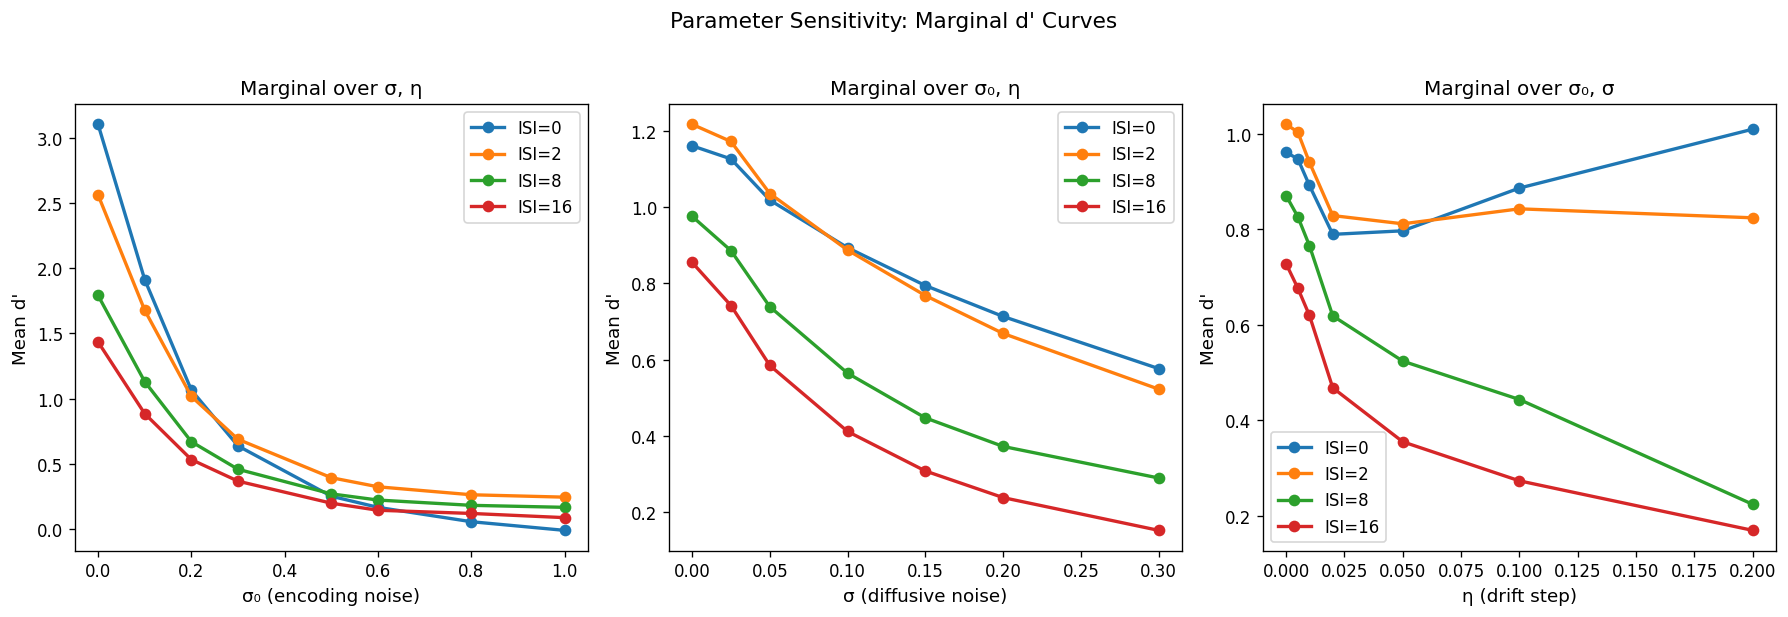

In [21]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# d' vs sigma0 (avg over sigma, eta)
ax = axes[0]
for isi in ISI_VALUES:
    marginal = np.nanmean(results[isi], axis=(1, 2))  # avg over sigma, eta
    ax.plot(sigma0_grid, marginal, 'o-', linewidth=2, label=f'ISI={isi}')
ax.set_xlabel('\u03c3\u2080 (encoding noise)', fontsize=11)
ax.set_ylabel("Mean d'", fontsize=11)
ax.set_title('Marginal over \u03c3, \u03b7', fontsize=12)
ax.legend()

# d' vs sigma (avg over sigma0, eta)
ax = axes[1]
for isi in ISI_VALUES:
    marginal = np.nanmean(results[isi], axis=(0, 2))  # avg over sigma0, eta
    ax.plot(sigma_grid, marginal, 'o-', linewidth=2, label=f'ISI={isi}')
ax.set_xlabel('\u03c3 (diffusive noise)', fontsize=11)
ax.set_ylabel("Mean d'", fontsize=11)
ax.set_title('Marginal over \u03c3\u2080, \u03b7', fontsize=12)
ax.legend()

# d' vs eta (avg over sigma0, sigma)
ax = axes[2]
for isi in ISI_VALUES:
    marginal = np.nanmean(results[isi], axis=(0, 1))  # avg over sigma0, sigma
    ax.plot(eta_grid, marginal, 'o-', linewidth=2, label=f'ISI={isi}')
ax.set_xlabel('\u03b7 (drift step)', fontsize=11)
ax.set_ylabel("Mean d'", fontsize=11)
ax.set_title('Marginal over \u03c3\u2080, \u03c3', fontsize=12)
ax.legend()

fig.suptitle('Parameter Sensitivity: Marginal d\' Curves', fontsize=13, y=1.02)
fig.tight_layout()
plt.show()